# Data Cleaning
Use prem data for exploratory data analysis

In [1]:
import pandas as pd
from pathlib import Path


def load_prem_data(year) -> pd.DataFrame:
    """Load one season's CSV file as a pandas DataFrame."""
    # Build the path to the raw football-data CSV.
    csv_file = Path(
        "/accounts/masters/gautierep/footy_prediction/footy-prediction"
    ) / "data" / "raw" / "football_data" / f"{year}.csv"

    if not csv_file.exists():
        raise FileNotFoundError(f"Could not find {csv_file}")

    # latin-1 handles the source file's special characters safely.
    return pd.read_csv(csv_file, encoding="latin-1")


# Load the 2025/26 Premier League season.
df_2526 = load_prem_data(2526)
df_2526.head()
list(df_2526.columns)

['ï»¿Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'Referee',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BFDH',
 'BFDD',
 'BFDA',
 'BMGMH',
 'BMGMD',
 'BMGMA',
 'BVH',
 'BVD',
 'BVA',
 'BWH',
 'BWD',
 'BWA',
 'CLH',
 'CLD',
 'CLA',
 'LBH',
 'LBD',
 'LBA',
 'PSH',
 'PSD',
 'PSA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'BFEH',
 'BFED',
 'BFEA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'BFE>2.5',
 'BFE<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'BFEAHH',
 'BFEAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BFDCH',
 'BFDCD',
 'BFDCA',
 'BMGMCH',
 'BMGMCD',
 'BMGMCA',
 'BVCH',
 'BVCD',
 'BVCA',
 'BWCH',
 'BWCD',
 'BWCA',
 'CLCH',
 'CLCD',
 'CLCA',
 'LBCH',
 'LBCD',
 'LBCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 '

In [7]:
import duckdb


# Create one DuckDB connection for the SQL cells below.
con = duckdb.connect()


def load_season(season) -> pd.DataFrame:
    """Load any four-digit season file and register it as SQL table matches."""
    season = str(season)
    if len(season) != 4 or not season.isdigit():
        raise ValueError("season must be a four-digit value such as 2526")

    season_file = Path(
        "/accounts/masters/gautierep/footy_prediction/footy-prediction"
    ) / "data" / "raw" / "football_data" / f"{season}.csv"

    if not season_file.exists():
        raise FileNotFoundError(f"Could not find {season_file}")

    season_df = pd.read_csv(season_file, encoding="latin-1")

    # Replace the matches table so SQL always uses the currently loaded season.
    con.register("matches", season_df)
    return season_df


# Load the default season. Change this to load another 2x2x.csv file.
df_2526 = load_season(2526)

# Test the SQL connection and table registration.
con.sql("SELECT * FROM matches LIMIT 5")

┌─────────┬────────────┬─────────┬─────────────┬─────────────┬───────┬───────┬─────────┬───────┬───────┬─────────┬───────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬──────────┬──────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┬─────────┬─────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬─

In [ ]:
# Create match-level and team-history SQL tables.
con.sql("""
CREATE OR REPLACE TEMP TABLE matches_data AS
WITH parsed_matches AS (
    SELECT
        try_strptime(
            CAST("Date" AS VARCHAR)
            || ' '
            || COALESCE(CAST("Time" AS VARCHAR), '00:00'),
            '%d/%m/%Y %H:%M'
        ) AS kickoff,
        1 / average_home_odds AS market_home_odds,
        1 / average_draw_odds AS market_draw_odds,
        1 / average_away_odds AS market_away_odds,
        *
    FROM matches
)
SELECT
    ROW_NUMBER() OVER (
        ORDER BY kickoff, home_team, away_team
    ) AS match_id,
    *
FROM parsed_matches
;

CREATE OR REPLACE TEMP TABLE market_prob AS
SELECT
    match_id,
    market_home_odds / (market_home_odds + market_draw_odds + market_away_odds) AS market_home_prob,
    market_draw_odds / (market_home_odds + market_draw_odds + market_away_odds) AS market_draw_prob,
    market_away_odds / (market_home_odds + market_draw_odds + market_away_odds) AS market_away_prob,
FROM matches_data
;

# ADD THIS BACK TO THE matches_data table using left join to add the market probabilities to the matches_data table
CREATE OR REPLACE TEMP TABLE matches_data AS
SELECT
    m.*,
    mp.market_home_prob,
    mp.market_draw_prob,
    mp.market_away_prob
FROM matches_data m
LEFT JOIN market_prob mp ON m.match_id = mp.match_id
;

CREATE OR REPLACE TEMP TABLE home_history AS
SELECT
    match_id,
    kickoff,
    HomeTeam AS team,
    'home' AS venue,
    FTHG AS goals_for,
    FTAG AS goals_against,
    HF AS fouls_for,
    HC AS corners_for,
    HYC AS yellow_cards_for,
    HRC AS red_cards_for,
    CASE FTR
        WHEN 'H' THEN 3
        WHEN 'D' THEN 1
        WHEN 'A' THEN 0
    END AS points,
    HS AS shots_for,
    HST AS shots_on_target_for
FROM matches_data;

CREATE OR REPLACE TEMP TABLE away_history AS
SELECT
    match_id,
    kickoff,
    AwayTeam AS team,
    'away' AS venue,
    FTAG AS goals_for,
    FTHG AS goals_against,
    AF AS fouls_for,
    AC AS corners_for,
    AYC AS yellow_cards_for,
    ARC AS red_cards_for,
    CASE FTR
        WHEN 'H' THEN 0
        WHEN 'D' THEN 1
        WHEN 'A' THEN 3
    END AS points,
    AS AS shots_for,
    AST AS shots_on_target_for
FROM matches_data;

CREATE OR REPLACE TEMP TABLE history AS
SELECT * FROM home_history
UNION ALL
SELECT * FROM away_history;
""")

# Inspect the combined team-perspective table.
con.sql("""
SELECT *
FROM history
ORDER BY kickoff, match_id, venue
LIMIT 10
""")

┌─────────────────────┬──────────┬─────────────┬─────────────┬─────────┬─────────────────────┬─────────────────────┬─────────────────────┐
│       kickoff       │ match_id │  HomeTeam   │  AwayTeam   │   FTR   │  market_home_prob   │  market_draw_prob   │  market_away_prob   │
│      timestamp      │  int64   │   varchar   │   varchar   │ varchar │       double        │       double        │       double        │
├─────────────────────┼──────────┼─────────────┼─────────────┼─────────┼─────────────────────┼─────────────────────┼─────────────────────┤
│ 2025-08-15 20:00:00 │        1 │ Liverpool   │ Bournemouth │ H       │  0.7633587786259541 │ 0.16778523489932887 │ 0.12033694344163658 │
│ 2025-08-16 12:30:00 │        2 │ Aston Villa │ Newcastle   │ D       │  0.4347826086956522 │  0.2808988764044944 │  0.3401360544217687 │
│ 2025-08-16 15:00:00 │        3 │ Brighton    │ Fulham      │ D       │  0.5208333333333334 │ 0.27624309392265195 │  0.2557544757033248 │
│ 2025-08-16 15:00:00 │    

In [6]:
def build_prematch_features(matches: pd.DataFrame) -> pd.DataFrame:
    """Create leakage-safe features available before each match."""
    data = matches.copy()
    data = data.rename(columns={"ï»¿Div": "Div"})

    # Combine date and time so all matches can be ordered chronologically.
    data["kickoff"] = pd.to_datetime(
        data["Date"].astype(str) + " " + data["Time"].fillna("00:00").astype(str),
        dayfirst=True,
        errors="coerce",
    )
    data = data.sort_values("kickoff").reset_index(drop=True)
    data["match_id"] = range(len(data))

    # Convert average bookmaker odds into normalized implied probabilities.
    data["market_home_prob"] = 1 / data["AvgH"]
    data["market_draw_prob"] = 1 / data["AvgD"]
    data["market_away_prob"] = 1 / data["AvgA"]
    # since bookmakers make a cut on their odds notmalise the probabilities so that they add to one 
    overround = data[
        ["market_home_prob", "market_draw_prob", "market_away_prob"]
    ].sum(axis=1)
    for outcome in ["home", "draw", "away"]:
        data[f"market_{outcome}_prob_fair"] = (
            data[f"market_{outcome}_prob"] / overround
        )

    # Represent each match once from each team's perspective.
    home_history = pd.DataFrame({
        "match_id": data["match_id"],
        "kickoff": data["kickoff"],
        "team": data["HomeTeam"],
        "venue": "home",
        "goals_for": data["FTHG"],
        "goals_against": data["FTAG"],
        "fouls_for": data["HF"],
        "corners_for": data["HC"],
        "yellow_cards_for": data["HY"],
        "red_cards_for": data["HR"],
        "points": data["FTR"].map({"H": 3, "D": 1, "A": 0}),
        "shots_for": data["HS"],
        "shots_on_target_for": data["HST"],
    })
    away_history = pd.DataFrame({
        "match_id": data["match_id"],
        "kickoff": data["kickoff"],
        "team": data["AwayTeam"],
        "venue": "away",
        "goals_for": data["FTAG"],
        "goals_against": data["FTHG"],
        "fouls_for": data["AF"],
        "corners_for": data["AC"],
        "yellow_cards_for": data["AY"],
        "red_cards_for": data["AR"],
        "points": data["FTR"].map({"H": 0, "D": 1, "A": 3}),
        "shots_for": data["AS"],
        "shots_on_target_for": data["AST"],
    })
    history = pd.concat([home_history, away_history], ignore_index=True)
    history = history.sort_values(["team", "kickoff", "match_id"])

    # Overall team form, using only matches before the current match.
    rolling_columns = [
        "points",
        "goals_for",
        "goals_against",
        "shots_for",
        "shots_on_target_for",
        "fouls_for",
        "corners_for",
        "yellow_cards_for",
        "red_cards_for",
    ]
    feature_frames = []
    # group by the teams but ignore the "team" column as it is not needed for the rolling calculations
    for _, team_history in history.groupby("team", sort=False):
        team_history = team_history.copy()
        # calculate the number of rest days between matches for each team
        team_history["rest_days"] = (
            team_history["kickoff"].diff().dt.total_seconds() / 86400
        )
        # loop over the two rolling averages and the selected columns
        for window in [5, 10]:
            for column in rolling_columns:
                # shift(1) prevents the current match result entering its features.
                team_history[f"{column}_last_{window}"] = (
                    team_history[column] # get the column values for the team
                    .shift(1) # shift them by one to avoid using the current match's data
                    .rolling(window, min_periods=1) # calc rolling mean allowing for fewer than window matches
                    .mean()
                )
        feature_frames.append(team_history) # make a list of the team history dataframes with the new rolling features added

    history_features = pd.concat(feature_frames) # concatenate the list of dataframes into a single dataframe with all teams' history features

    # Venue-specific form for the three requested columns.
    venue_columns = ["points", "goals_for", "goals_against"]
    venue_feature_frames = []
    for _, team_venue_history in history.groupby(["team", "venue"], sort=False):
        team_venue_history = team_venue_history.copy()
        venue = team_venue_history["venue"].iloc[0]
        for window in [5, 10]:
            for column in venue_columns:
                # The venue group means home form uses previous home matches only,
                # and away form uses previous away matches only.
                team_venue_history[
                    f"{column}_{venue}_last_{window}"
                ] = (
                    team_venue_history[column]
                    .shift(1)
                    .rolling(window, min_periods=1)
                    .mean()
                )
        venue_feature_frames.append(team_venue_history)

    # This concatenation is required before the venue features can be merged.
    venue_history_features = pd.concat(venue_feature_frames)

    # create column names for every rolling feature
    rolling_features = [
        f"{column}_last_{window}"
        for window in [5, 10]
        for column in rolling_columns
    ]
    selected_features = ["match_id", "venue", "rest_days", *rolling_features] # creates list of columns to keep

    # Attach overall history to the home and away team separately.
    home_features = history_features[
        history_features["venue"] == "home" # keeps only home matches
    ][selected_features].drop(columns="venue") # selects features to keep drops venue column as no longer needed
    home_features = home_features.rename(columns={
        column: f"home_{column}" # adds home to evey featurn column but match_id  
        for column in home_features.columns
        if column != "match_id"
    })

    # same for away team
    away_features = history_features[
        history_features["venue"] == "away"
    ][selected_features].drop(columns="venue")
    away_features = away_features.rename(columns={
        column: f"away_{column}"
        for column in away_features.columns
        if column != "match_id"
    })

    # Select the venue-specific features relevant to each side of the match.
    home_venue_columns = [
        "match_id",
        "points_home_last_5",
        "points_home_last_10",
        "goals_for_home_last_5",
        "goals_for_home_last_10",
        "goals_against_home_last_5",
        "goals_against_home_last_10",
    ]
    away_venue_columns = [
        "match_id",
        "points_away_last_5",
        "points_away_last_10",
        "goals_for_away_last_5",
        "goals_for_away_last_10",
        "goals_against_away_last_5",
        "goals_against_away_last_10",
    ]
    # does the same for renaming the venue specific columns for home and away teams
    home_venue_features = venue_history_features[
        venue_history_features["venue"] == "home"
    ][home_venue_columns].rename(columns={
        column: f"home_{column}"
        for column in home_venue_columns
        if column != "match_id"
    })
    away_venue_features = venue_history_features[
        venue_history_features["venue"] == "away"
    ][away_venue_columns].rename(columns={
        column: f"away_{column}"
        for column in away_venue_columns
        if column != "match_id"
    })

    # Merge overall and venue-specific history back onto each match.
    features = data.merge(home_features, on="match_id")
    features = features.merge(away_features, on="match_id")
    features = features.merge(home_venue_features, on="match_id")
    features = features.merge(away_venue_features, on="match_id")

    # Compare recent overall form between the two teams.
    features["points_difference_last_5"] = (
        features["home_points_last_5"] - features["away_points_last_5"]
    )
    features["goals_difference_last_5"] = (
        features["home_goals_for_last_5"] - features["away_goals_for_last_5"]
    )
    return features


# Build the model-ready feature table for the loaded season.
prematch_2526 = build_prematch_features(df_2526)
prematch_2526[[
    "HomeTeam",
    "AwayTeam",
    "FTR",
    "home_points_last_5",
    "away_points_last_5",
    "home_points_home_last_5",
    "away_points_away_last_5",
    "home_goals_for_home_last_5",
    "away_goals_for_away_last_5",
    "market_home_prob_fair",
    "market_draw_prob_fair",
    "market_away_prob_fair",
]].head()
# len(list(prematch_2526.columns))
prematch_2526.head(10)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,home_goals_against_home_last_5,home_goals_against_home_last_10,away_points_away_last_5,away_points_away_last_10,away_goals_for_away_last_5,away_goals_for_away_last_10,away_goals_against_away_last_5,away_goals_against_away_last_10,points_difference_last_5,goals_difference_last_5
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,E0,16/08/2025,17:30,Wolves,Man City,0,4,A,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,E0,17/08/2025,14:00,Chelsea,Crystal Palace,0,0,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,E0,17/08/2025,14:00,Nott'm Forest,Brentford,3,1,H,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,E0,17/08/2025,16:30,Man United,Arsenal,0,1,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,E0,18/08/2025,20:00,Leeds,Everton,1,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature-engineering logic

The `build_prematch_features` function creates variables that could have been known immediately before each match. It starts by copying the raw table, cleaning the first column name, and combining the date and time into a single `kickoff` column so every match can be ordered chronologically.

The average bookmaker odds are converted into implied probabilities using `1 / odds`. These probabilities include the bookmaker's margin, so the three values are divided by their total (`overround`) to create normalized market probabilities that sum to one. These are useful baseline features because they summarize the market's pre-match expectations.

The match table is then reshaped into team-history rows. Each match produces one row from the home team's perspective and one from the away team's perspective. This makes it possible to calculate each team's previous points, goals, shots, and shots on target consistently, regardless of whether the team played at home or away.

For each team, the function calculates:

- Rest days since the previous match
- Mean points over the previous 5 and 10 matches
- Mean goals scored over the previous 5 and 10 matches
- Mean goals conceded over the previous 5 and 10 matches
- Mean shots and shots on target over the previous 5 and 10 matches

The important leakage safeguard is `.shift(1)`. It moves the history back by one match before calculating each rolling mean. Therefore, a match's own result is never used to create its predictors. The first match for each team has missing historical features because no earlier information exists.

Finally, the home and away history features are merged back onto the original match rows. Difference features, such as `points_difference_last_5`, compare the recent form of the two teams. The resulting `prematch_2526` dataframe contains both the original target column, `FTR`, and the pre-match predictors for later modelling.

1. Recent form
- overall_points_last_5
- overall_points_last_10
- overall_goals_scored_last_5
- overall_goals_conceded_last_5
- overall_shots_last_5
- overall_shots_on_target_last_5
- overall_corners_last_5

2. Venue strength
- home_points_last_5
- home_points_last_10
- home_goals_scored_last_5
- home_goals_conceded_last_5
- away_points_last_5
- away_points_last_10
- away_goals_scored_last_5
- away_goals_conceded_last_5

3. Matchup differences
- home_team_goals_scored_last_5
- away_team_goals_scored_last_5

# Data validation

Take match_id 100 Tottenham vs Man U 

Manually calc away_points_last_5, home_points_home_last_5

below we see that sums are equivalent

In [5]:
list(prematch_2526.columns)

prematch_2526["HTW"]

prematch_2526["HTD"]

['Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'Referee',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BFDH',
 'BFDD',
 'BFDA',
 'BMGMH',
 'BMGMD',
 'BMGMA',
 'BVH',
 'BVD',
 'BVA',
 'BWH',
 'BWD',
 'BWA',
 'CLH',
 'CLD',
 'CLA',
 'LBH',
 'LBD',
 'LBA',
 'PSH',
 'PSD',
 'PSA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'BFEH',
 'BFED',
 'BFEA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'BFE>2.5',
 'BFE<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'BFEAHH',
 'BFEAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BFDCH',
 'BFDCD',
 'BFDCA',
 'BMGMCH',
 'BMGMCD',
 'BMGMCA',
 'BVCH',
 'BVCD',
 'BVCA',
 'BWCH',
 'BWCD',
 'BWCA',
 'CLCH',
 'CLCD',
 'CLCA',
 'LBCH',
 'LBCD',
 'LBCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 'Avg

In [4]:
data = prematch_2526[[
    # Info about match
    "match_id",
    "kickoff",
    "HomeTeam",
    "AwayTeam",
    "FTR",
    "HS",
    "AS",
    # Recent form
    "home_points_last_5",
    "away_points_last_5",
    "home_points_last_10",
    "away_points_last_10",
    # venue strength
    "home_points_home_last_5",
    "away_points_away_last_5",
    "home_goals_for_home_last_5",
    "away_goals_for_away_last_5",
    "market_home_prob_fair",
    "market_draw_prob_fair",
    "market_away_prob_fair",
    # difference in recent form
    "goals_difference_last_5",
    "points_difference_last_5",
    # extra features
    "home_shots_on_target_for_last_5",
    "away_shots_on_target_for_last_5",
    "home_fouls_for_last_5",
    "away_fouls_for_last_5",
    "home_corners_for_last_5",
    "away_corners_for_last_5",
]]


KeyError: "['HG', 'AG'] not in index"

In [25]:


temp = df_2526[((df_2526["HomeTeam"] == "Tottenham") | (df_2526["AwayTeam"] == "Tottenham") | 
        (df_2526["HomeTeam"] == "Man United") | (df_2526["AwayTeam"] == "Man United"))]

temp["kickoff"] = pd.to_datetime(
    temp["Date"].astype(str) + " " + temp["Time"].fillna("00:00").astype(str),
    dayfirst=True,
    errors="coerce",
)

temp = temp[(temp["kickoff"] > "2025-08-10") & (temp["kickoff"] < "2025-11-09")]
temp[temp["HomeTeam"] == "Tottenham"][["kickoff", "HomeTeam", "AwayTeam", "FTR"]]

/tmp/ipykernel_2104429/3119902237.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["kickoff"] = pd.to_datetime(


,kickoff,HomeTeam,AwayTeam,FTR
4,2025-08-16 15:00:00,Tottenham,Burnley,H
23,2025-08-30 15:00:00,Tottenham,Bournemouth,A
56,2025-09-27 20:00:00,Tottenham,Wolves,D
77,2025-10-19 14:00:00,Tottenham,Aston Villa,A
95,2025-11-01 17:30:00,Tottenham,Chelsea,A
100,2025-11-08 12:30:00,Tottenham,Man United,D


{'H': 0.652, 'D': 0.249, 'A': 0.099}


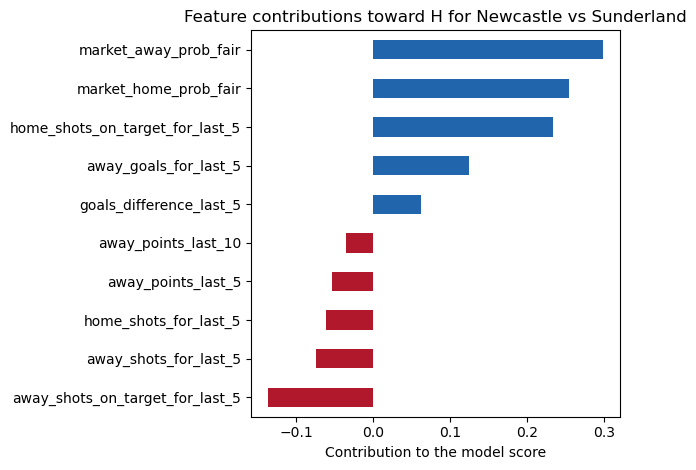

In [ ]:
columns